# Bài thực hành: Titanic với Machine Learning và PyTorch

Trong bài thực hành này, ta xây dựng **một quy trình Machine Learning hoàn chỉnh** cho bài toán Titanic:

**Dữ liệu → Khám phá → Tiền xử lý → Feature Engineering → Tìm đặc trưng tốt → Machine Learning → PyTorch → Đánh giá → Kaggle Submission**

## Mục tiêu

Sau bài này, sinh viên có thể:

- Đọc và khảo sát dữ liệu Titanic.
- Phân biệt biến số, biến phân loại và nhãn.
- Kiểm tra missing values, duplicate và phân bố lớp.
- Trực quan hóa mối liên hệ giữa các thuộc tính và khả năng sống sót.
- Thực hiện feature engineering từ các cột gốc.
- Tiền xử lý bằng `ColumnTransformer`.
- Tránh **data leakage**.
- Đánh giá đặc trưng bằng **Mutual Information**.
- Chọn số lượng đặc trưng tốt bằng **Cross-Validation + SelectKBest**.
- So sánh Logistic Regression, Random Forest và SVM.
- Xây dựng mạng MLP bằng PyTorch.
- So sánh PyTorch dùng toàn bộ đặc trưng và PyTorch dùng đặc trưng đã chọn.
- Đánh giá bằng Accuracy, Precision, Recall, F1, ROC-AUC và Confusion Matrix.
- Tạo file `submission_titanic_pytorch.csv` để nộp Kaggle.

> Notebook giả sử `train.csv` và `test.csv` của cuộc thi Kaggle Titanic nằm cùng thư mục với notebook.

## 1. Import thư viện

In [1]:
import random
import time
import re
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)
print("PyTorch:", torch.__version__)
print("Device :", "cuda" if torch.cuda.is_available() else "cpu")

NumPy  : 2.4.4
Pandas : 3.0.2
PyTorch: 2.14.1+cu130
Device : cpu


## 2. Load Data

Kaggle cung cấp:

- `train.csv`: có cột `Survived`
- `test.csv`: không có `Survived`

Nhãn:

- `0`: không sống sót
- `1`: sống sót

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)

train.head()

Train shape: (891, 12)
Test shape : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 3. Khảo sát dữ liệu

Các câu hỏi cần trả lời trước khi xây dựng mô hình:

1. Dữ liệu có bao nhiêu cột?
2. Kiểu dữ liệu của từng cột?
3. Cột nào bị thiếu?
4. Tỷ lệ sống sót có cân bằng không?
5. Thuộc tính nào có vẻ liên quan tới `Survived`?

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
print("Missing values - TRAIN")
display(train.isnull().sum().sort_values(ascending=False).to_frame("missing"))

print("\nMissing values - TEST")
display(test.isnull().sum().sort_values(ascending=False).to_frame("missing"))

Missing values - TRAIN


,missing
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0



Missing values - TEST


,missing
Cabin,327
Age,86
Fare,1
Name,0
Pclass,0
PassengerId,0
Sex,0
Parch,0
SibSp,0
Ticket,0


In [6]:
print("Số dòng duplicate trong train:", train.duplicated().sum())
print("Số dòng duplicate trong test :", test.duplicated().sum())

Số dòng duplicate trong train: 0
Số dòng duplicate trong test : 0


In [7]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 4. Phân tích nhãn `Survived`

Survived
0    549
1    342
Name: count, dtype: int64

Tỷ lệ:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


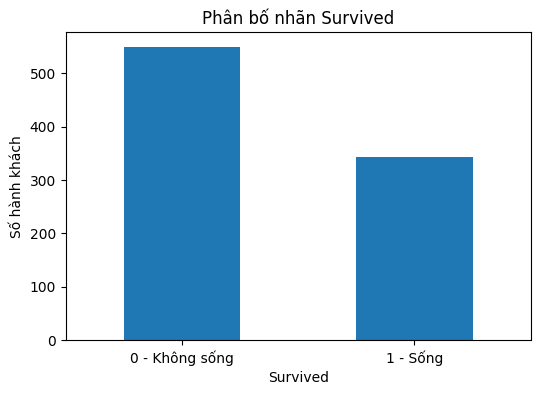

In [8]:
survival_counts = train["Survived"].value_counts().sort_index()

print(survival_counts)
print("\nTỷ lệ:")
print(train["Survived"].value_counts(normalize=True).sort_index())

ax = survival_counts.plot(kind="bar", figsize=(6, 4))
ax.set_title("Phân bố nhãn Survived")
ax.set_xlabel("Survived")
ax.set_ylabel("Số hành khách")
ax.set_xticklabels(["0 - Không sống", "1 - Sống"], rotation=0)
plt.show()

## 5. EDA: tìm dấu hiệu của các đặc trưng tốt

Ta khảo sát một số biến quan trọng:

- `Sex`
- `Pclass`
- `Age`
- `Fare`
- `Embarked`
- `SibSp`
- `Parch`

Mục đích của EDA không phải để kết luận tuyệt đối, mà để hình thành giả thuyết trước khi kiểm chứng bằng mô hình.

In [9]:
survival_by_sex = pd.crosstab(
    train["Sex"],
    train["Survived"],
    normalize="index"
)

survival_by_sex

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


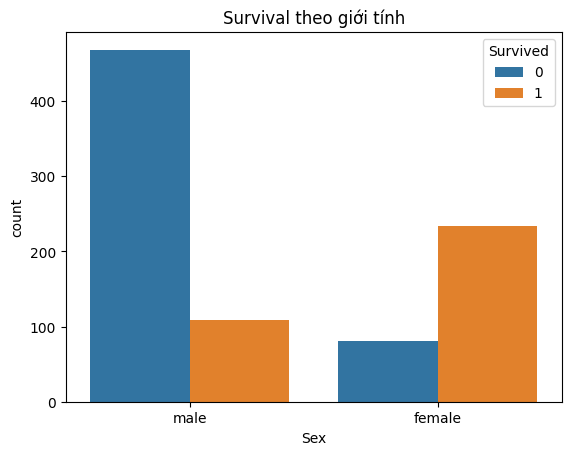

In [10]:
sns.countplot(data=train, x="Sex", hue="Survived")
plt.title("Survival theo giới tính")
plt.show()

In [11]:
survival_by_class = pd.crosstab(
    train["Pclass"],
    train["Survived"],
    normalize="index"
)

survival_by_class

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


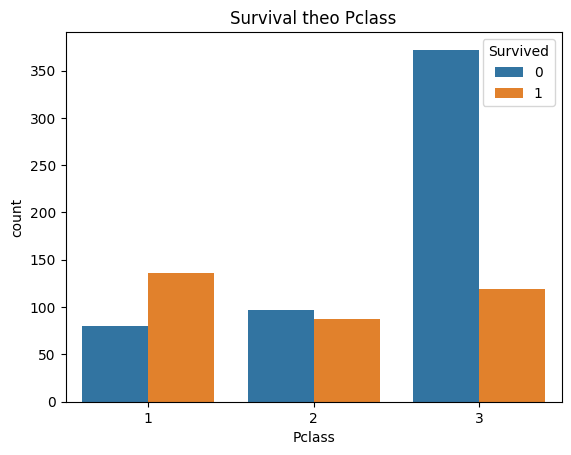

In [12]:
sns.countplot(data=train, x="Pclass", hue="Survived")
plt.title("Survival theo Pclass")
plt.show()

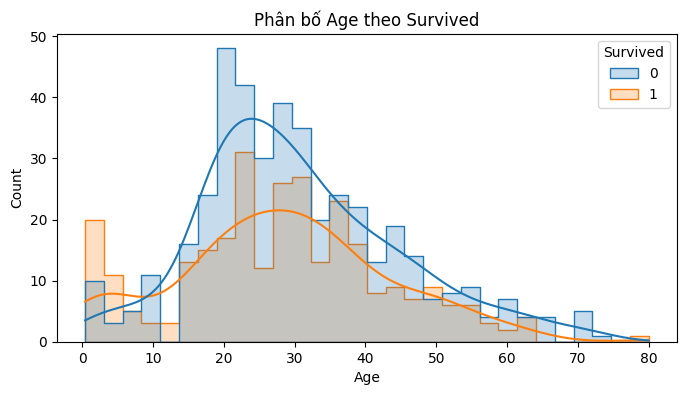

In [13]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Phân bố Age theo Survived")
plt.show()

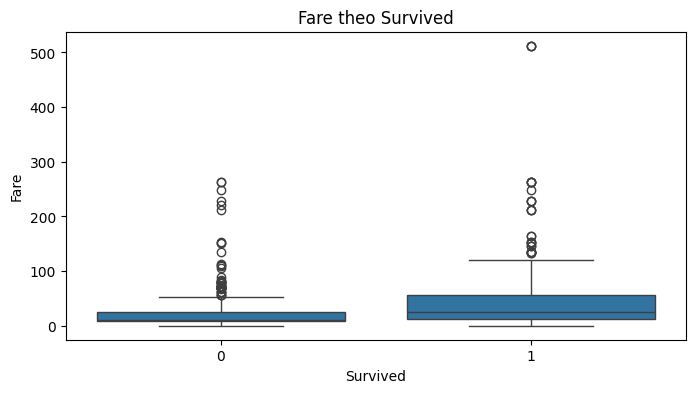

In [14]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=train,
    x="Survived",
    y="Fare"
)

plt.title("Fare theo Survived")
plt.show()

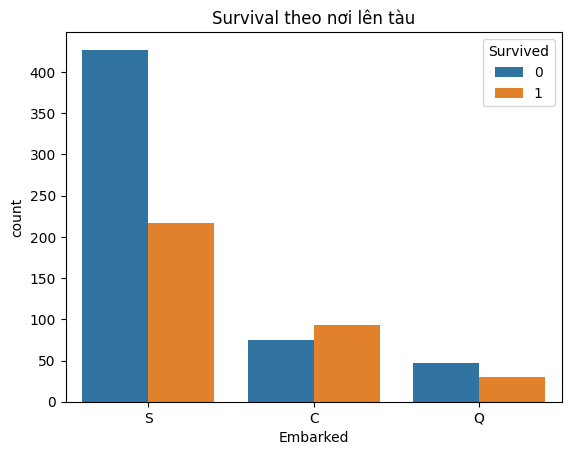

In [15]:
sns.countplot(data=train, x="Embarked", hue="Survived")
plt.title("Survival theo nơi lên tàu")
plt.show()

## 6. Feature Engineering

Dữ liệu Titanic có một số thông tin hữu ích chưa được biểu diễn trực tiếp.

Ta tạo thêm:

### `Title`
Lấy danh xưng từ `Name`, ví dụ:

- Mr
- Mrs
- Miss
- Master
- Rare

### `FamilySize`

$$
FamilySize = SibSp + Parch + 1
$$

### `IsAlone`

- `1`: đi một mình
- `0`: đi cùng gia đình

### `CabinDeck`

Lấy ký tự đầu tiên của `Cabin`.

### `FarePerPerson`

$$
FarePerPerson = \frac{Fare}{FamilySize}
$$

Các feature này được tạo **không sử dụng nhãn `Survived`**, vì vậy không gây target leakage.

In [16]:
def extract_title(name):
    match = re.search(r",\s*([^.]*)\.", str(name))

    if match:
        title = match.group(1).strip()
    else:
        return "Rare"

    # Chuẩn hóa một số cách gọi tương đương
    replacements = {
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    }

    title = replacements.get(title, title)

    common_titles = {"Mr", "Mrs", "Miss", "Master"}

    if title not in common_titles:
        title = "Rare"

    return title


def feature_engineering(df):
    data = df.copy()

    data["Title"] = data["Name"].apply(extract_title)

    data["FamilySize"] = (
        data["SibSp"]
        + data["Parch"]
        + 1
    )

    data["IsAlone"] = (
        data["FamilySize"] == 1
    ).astype(int)

    data["CabinDeck"] = (
        data["Cabin"]
        .fillna("Unknown")
        .astype(str)
        .str[0]
    )

    data["FarePerPerson"] = (
        data["Fare"]
        / data["FamilySize"]
    )

    return data


train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

train_fe[
    [
        "Name",
        "Title",
        "SibSp",
        "Parch",
        "FamilySize",
        "IsAlone",
        "Cabin",
        "CabinDeck",
        "Fare",
        "FarePerPerson"
    ]
].head(10)

,Name,Title,SibSp,Parch,FamilySize,IsAlone,Cabin,CabinDeck,Fare,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,1,0,2,0,NaN,U,7.2500,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,1,0,2,0,C85,C,71.2833,35.64165
2,"Heikkinen, Miss. Laina",Miss,0,0,1,1,NaN,U,7.9250,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,0,2,0,C123,C,53.1000,26.55000
4,"Allen, Mr. William Henry",Mr,0,0,1,1,NaN,U,8.0500,8.05000
5,"Moran, Mr. James",Mr,0,0,1,1,NaN,U,8.4583,8.45830
6,"McCarthy, Mr. Timothy J",Mr,0,0,1,1,E46,E,51.8625,51.86250
7,"Palsson, Master. Gosta Leonard",Master,3,1,5,0,NaN,U,21.0750,4.21500
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,0,2,3,0,NaN,U,11.1333,3.71110
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,1,0,2,0,NaN,U,30.0708,15.03540


In [17]:
print("Phân bố Title:")
display(train_fe["Title"].value_counts())

print("\nPhân bố CabinDeck:")
display(train_fe["CabinDeck"].value_counts())

Phân bố Title:


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


Phân bố CabinDeck:


CabinDeck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

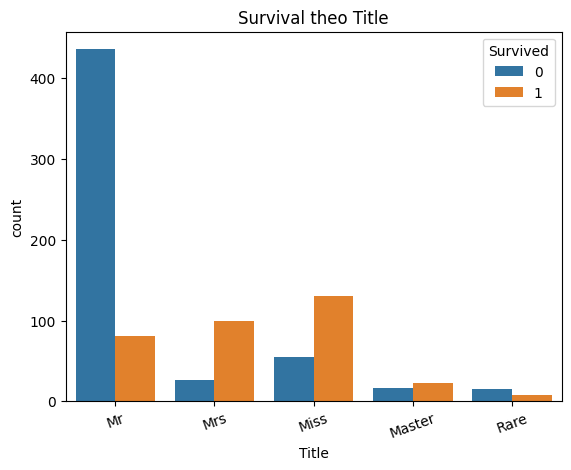

In [18]:
sns.countplot(
    data=train_fe,
    x="Title",
    hue="Survived"
)

plt.title("Survival theo Title")
plt.xticks(rotation=20)
plt.show()

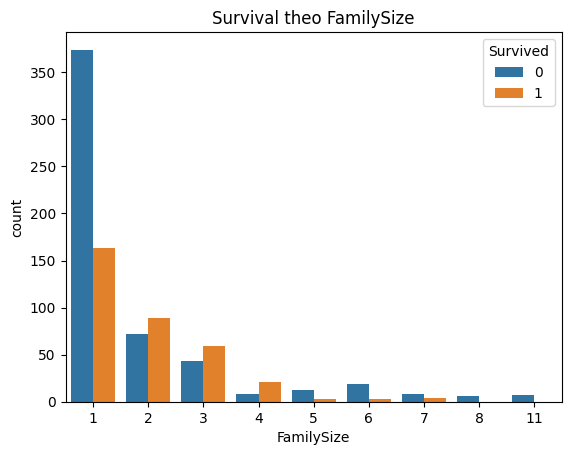

In [19]:
sns.countplot(
    data=train_fe,
    x="FamilySize",
    hue="Survived"
)

plt.title("Survival theo FamilySize")
plt.show()

## 7. Chọn các cột đầu vào

Ta không dùng trực tiếp:

- `PassengerId`: chủ yếu là định danh
- `Name`: đã rút ra `Title`
- `Ticket`: chuỗi phức tạp, chưa xử lý trong bài cơ bản
- `Cabin`: đã rút ra `CabinDeck`

### Biến số

- Age
- SibSp
- Parch
- Fare
- FamilySize
- FarePerPerson

### Biến phân loại

- Pclass
- Sex
- Embarked
- Title
- IsAlone
- CabinDeck

In [20]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "FarePerPerson"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "IsAlone",
    "CabinDeck"
]

feature_columns = (
    numeric_features
    + categorical_features
)

X = train_fe[feature_columns].copy()
y = train_fe["Survived"].copy()

X_kaggle = test_fe[feature_columns].copy()

print("Số feature gốc:", len(feature_columns))
print(feature_columns)

Số feature gốc: 12
['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'FarePerPerson', 'Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone', 'CabinDeck']


## 8. Chia Train / Validation trước khi học các tham số tiền xử lý

Ta giữ riêng validation để đánh giá cuối cùng.

```text
TRAIN
  ├── fit imputer
  ├── fit scaler
  ├── fit one-hot encoder
  └── chọn feature

VALIDATION
  └── chỉ transform
```

Điều này giúp tránh **data leakage**.

In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)

print("\nTỷ lệ Survived ở train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTỷ lệ Survived ở validation:")
print(y_val.value_counts(normalize=True).sort_index())

X_train: (712, 12)
X_val  : (179, 12)

Tỷ lệ Survived ở train:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Tỷ lệ Survived ở validation:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## 9. Xây dựng bộ tiền xử lý bằng `ColumnTransformer`

### Với biến số

1. Điền missing bằng median
2. StandardScaler

### Với biến phân loại

1. Điền missing bằng giá trị phổ biến nhất
2. One-Hot Encoding

`handle_unknown="ignore"` giúp xử lý trường hợp validation/test có category chưa xuất hiện trong train.

In [22]:
# Tương thích nhiều phiên bản scikit-learn
try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        onehot
    )
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 10. Baseline rất đơn giản

Trước khi dùng mô hình tốt hơn, ta tạo `DummyClassifier`.

Mục đích:

> Một mô hình Machine Learning phải tốt hơn cách luôn đoán lớp phổ biến nhất.

In [23]:
dummy = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_val)

dummy_acc = accuracy_score(y_val, dummy_pred)

print(f"Dummy Accuracy: {dummy_acc:.4f}")

Dummy Accuracy: 0.6145


## 11. Tìm đặc trưng tốt bằng Mutual Information

Khác Iris, Titanic có cả biến số và biến phân loại.

Do đó ta:

1. Fit `preprocessor` trên **X_train**
2. Chuyển dữ liệu thành ma trận số
3. Tính Mutual Information với `Survived`

Mutual Information càng lớn → feature chứa càng nhiều thông tin về nhãn.

In [24]:
preprocessor_mi = preprocessor

X_train_encoded = preprocessor_mi.fit_transform(X_train)

feature_names_encoded = (
    preprocessor_mi
    .get_feature_names_out()
)

print("Encoded shape:", X_train_encoded.shape)
print("Số feature sau encoding:", len(feature_names_encoded))

Encoded shape: (712, 30)
Số feature sau encoding: 30


In [25]:
mi_func = partial(
    mutual_info_classif,
    random_state=SEED
)

mi_scores = mi_func(
    X_train_encoded,
    y_train
)

mi_df = pd.DataFrame({
    "Feature": feature_names_encoded,
    "Mutual Information": mi_scores
}).sort_values(
    "Mutual Information",
    ascending=False
).reset_index(drop=True)

mi_df.head(20)

,Feature,Mutual Information
0,cat__Sex_male,0.160909
1,num__Fare,0.155851
2,cat__Sex_female,0.153899
3,cat__Title_Mr,0.149748
4,num__FarePerPerson,0.136120
5,num__FamilySize,0.072643
6,cat__CabinDeck_U,0.068565
7,cat__Title_Mrs,0.052296
8,cat__Title_Miss,0.046907
9,num__Parch,0.043116


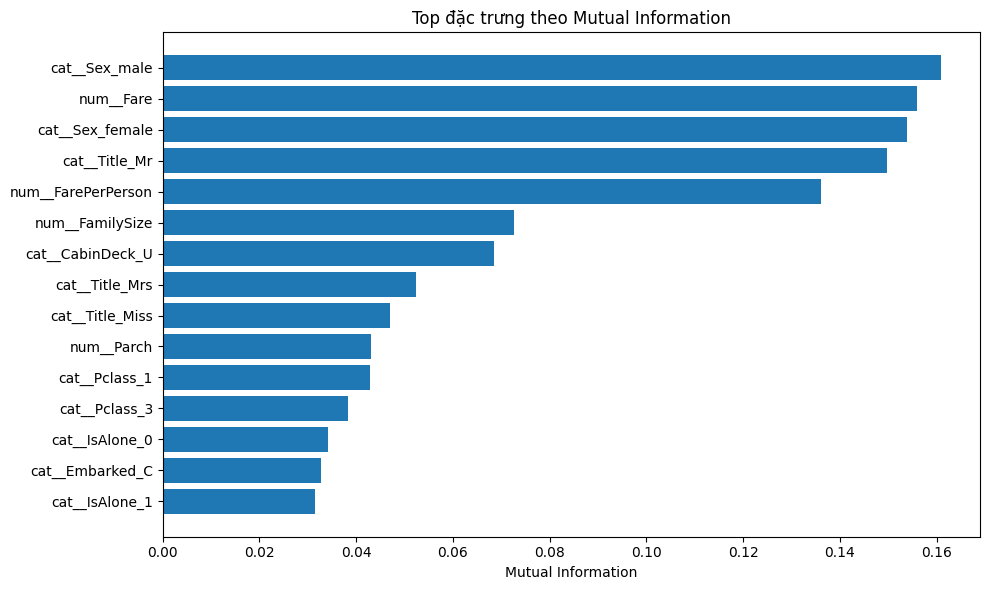

In [26]:
top_n = min(15, len(mi_df))

plt.figure(figsize=(10, 6))

top_mi = mi_df.head(top_n).sort_values(
    "Mutual Information"
)

plt.barh(
    top_mi["Feature"],
    top_mi["Mutual Information"]
)

plt.title("Top đặc trưng theo Mutual Information")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

## 12. Chọn số lượng feature bằng Cross-Validation

Chỉ nhìn Mutual Information chưa đủ.

Ta thử nhiều giá trị `k` của `SelectKBest`:

```text
Preprocessing
    ↓
SelectKBest(Mutual Information)
    ↓
Logistic Regression
```

Mỗi giá trị `k` được đánh giá bằng **5-fold Stratified Cross-Validation** trên tập train.

Validation bên ngoài vẫn chưa được sử dụng.
### Quy tắc chọn `k`: "1 sai số chuẩn" (1-SE rule)

Nếu chỉ chọn `k` có ROC-AUC cao nhất thì ROC-AUC gần như luôn tăng nhẹ khi thêm feature, nên kết quả thường là giữ **tất cả** feature và bước "chọn đặc trưng" không còn ý nghĩa.

Ta dùng quy tắc phổ biến:

> Chọn `k` **nhỏ nhất** có CV ROC-AUC không thấp hơn *(ROC-AUC tốt nhất − 1 sai số chuẩn)*.

Nghĩa là: chấp nhận mất một chút hiệu năng nằm trong khoảng nhiễu của Cross-Validation để đổi lấy mô hình **gọn hơn, ít overfit hơn, dễ giải thích hơn**.


In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

n_encoded = X_train_encoded.shape[1]

# Lưới k mịn hơn để thấy rõ đường cong "số feature vs hiệu năng"
candidate_k = [
    k for k in [3, 5, 8, 10, 12, 15, 18, 20, 25]
    if k < n_encoded
]

candidate_k.append("all")

feature_selection_results = []

for k in candidate_k:

    selector = SelectKBest(
        score_func=mi_func,
        k=k
    )

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("selector", selector),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1
    )

    n_folds = len(scores["test_roc_auc"])

    feature_selection_results.append({
        "k": k,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "SE ROC-AUC": scores["test_roc_auc"].std() / np.sqrt(n_folds)
    })

feature_selection_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_df


,k,CV Accuracy,CV F1,CV ROC-AUC,SE ROC-AUC
0,3,0.782330,0.727125,0.814846,0.015530
1,5,0.773939,0.719860,0.852291,0.008927
2,8,0.782311,0.723570,0.852896,0.010329
3,10,0.789323,0.737459,0.860383,0.012664
4,12,0.796375,0.750101,0.863298,0.012949
5,15,0.806254,0.760124,0.865711,0.014317
6,18,0.811859,0.767960,0.865678,0.015534
7,20,0.811839,0.766480,0.865833,0.010702
8,25,0.814646,0.770844,0.867088,0.010373
9,all,0.820270,0.775604,0.868825,0.008929


ROC-AUC cao nhất : 0.8688 (k = all, SE = 0.0089)
Ngưỡng 1-SE       : 0.8599
Best k (1-SE rule): 10
CV ROC-AUC tại k  : 0.8604


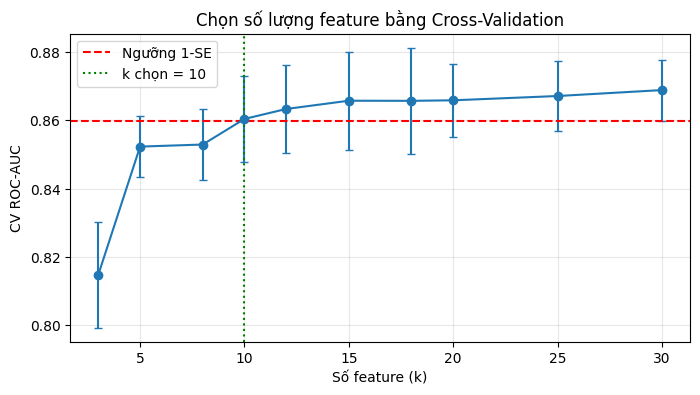

In [28]:
# Quy tắc 1-SE: chọn k NHỎ NHẤT có ROC-AUC >= (best - SE của best)
tmp = feature_selection_df.copy()

tmp["k_numeric"] = tmp["k"].apply(
    lambda x: n_encoded if x == "all" else int(x)
)

top_row = tmp.sort_values("CV ROC-AUC", ascending=False).iloc[0]

threshold = top_row["CV ROC-AUC"] - top_row["SE ROC-AUC"]

best_fs_row = (
    tmp[tmp["CV ROC-AUC"] >= threshold]
    .sort_values("k_numeric")
    .iloc[0]
)

best_k = best_fs_row["k"]
best_k = best_k if best_k == "all" else int(best_k)

print(
    f"ROC-AUC cao nhất : {top_row['CV ROC-AUC']:.4f} "
    f"(k = {top_row['k']}, SE = {top_row['SE ROC-AUC']:.4f})"
)
print(f"Ngưỡng 1-SE       : {threshold:.4f}")
print(f"Best k (1-SE rule): {best_k}")
print(f"CV ROC-AUC tại k  : {best_fs_row['CV ROC-AUC']:.4f}")

# Biểu đồ số feature vs ROC-AUC
plt.figure(figsize=(8, 4))
plt.errorbar(
    tmp["k_numeric"],
    tmp["CV ROC-AUC"],
    yerr=tmp["SE ROC-AUC"],
    marker="o",
    capsize=3
)
plt.axhline(threshold, color="red", linestyle="--", label="Ngưỡng 1-SE")
plt.axvline(best_fs_row["k_numeric"], color="green", linestyle=":", label=f"k chọn = {best_k}")
plt.xlabel("Số feature (k)")
plt.ylabel("CV ROC-AUC")
plt.title("Chọn số lượng feature bằng Cross-Validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 13. Xác định các feature đã được chọn

In [29]:
selector_best = SelectKBest(
    score_func=mi_func,
    k=best_k
)

X_train_selected = selector_best.fit_transform(
    X_train_encoded,
    y_train
)

selected_mask = selector_best.get_support()

selected_feature_names = feature_names_encoded[
    selected_mask
]

print("Số feature được chọn:", len(selected_feature_names))

for name in selected_feature_names:
    print("-", name)

Số feature được chọn: 10
- num__Parch
- num__Fare
- num__FamilySize
- num__FarePerPerson
- cat__Sex_female
- cat__Sex_male
- cat__Title_Miss
- cat__Title_Mr
- cat__Title_Mrs
- cat__CabinDeck_U


## 14. So sánh các mô hình Machine Learning

Ta so sánh:

- Logistic Regression
- Random Forest
- SVM RBF

Pipeline:

```text
Raw Data
   ↓
Imputation + Scaling + One-Hot
   ↓
SelectKBest
   ↓
Classifier
```

Dùng 5-fold Cross-Validation trên tập train.

In [30]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced",
        n_jobs=-1
    ),

    "SVM-RBF": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=SEED
    )
}

ml_results = []

for model_name, clf in models.items():

    pipe = Pipeline([
        ("preprocess", preprocessor),
        (
            "selector",
            SelectKBest(
                score_func=mi_func,
                k=best_k
            )
        ),
        ("model", clf)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        n_jobs=-1
    )

    ml_results.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

ml_results_df = pd.DataFrame(
    ml_results
).sort_values(
    "CV ROC-AUC",
    ascending=False
)

ml_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
1,Random Forest,0.814607,0.756712,0.765455,0.760192,0.863003
0,Logistic Regression,0.789323,0.708695,0.772795,0.737459,0.860383
2,SVM-RBF,0.804816,0.739905,0.761751,0.749833,0.845289


## 15. Huấn luyện Logistic Regression trên train và đánh giá validation

Logistic Regression được dùng làm baseline ML chính để so sánh với PyTorch.

In [31]:
lr_selected = Pipeline([
    ("preprocess", preprocessor),
    (
        "selector",
        SelectKBest(
            score_func=mi_func,
            k=best_k
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

lr_selected.fit(
    X_train,
    y_train
)

lr_pred = lr_selected.predict(
    X_val
)

lr_prob = lr_selected.predict_proba(
    X_val
)[:, 1]

acc_lr = accuracy_score(
    y_val,
    lr_pred
)

f1_lr = f1_score(
    y_val,
    lr_pred
)

auc_lr = roc_auc_score(
    y_val,
    lr_prob
)

print(f"Accuracy: {acc_lr:.4f}")
print(f"F1      : {f1_lr:.4f}")
print(f"ROC-AUC : {auc_lr:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_val,
        lr_pred
    )
)

Accuracy: 0.7821
F1      : 0.7234
ROC-AUC : 0.8441

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       110
           1       0.71      0.74      0.72        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



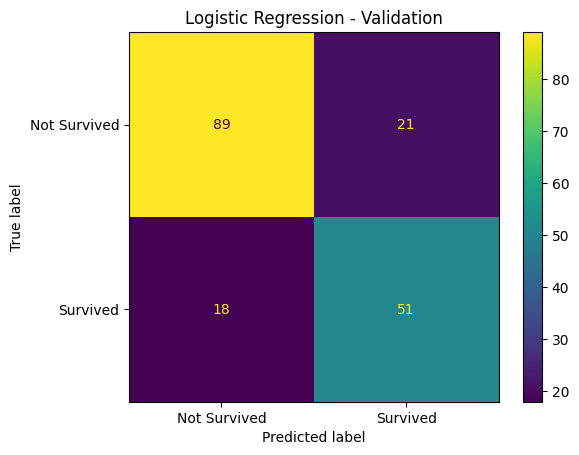

In [32]:
cm = confusion_matrix(
    y_val,
    lr_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Survived",
        "Survived"
    ]
)

disp.plot()
plt.title("Logistic Regression - Validation")
plt.show()

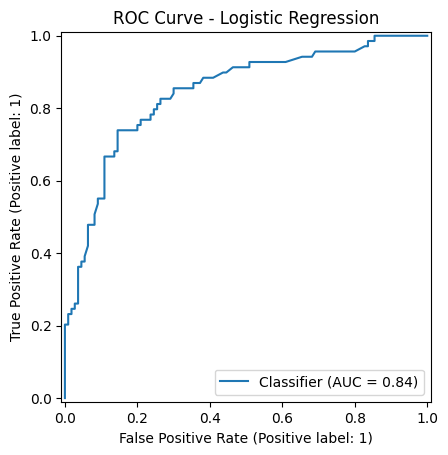

In [33]:
RocCurveDisplay.from_predictions(
    y_val,
    lr_prob
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

## 16. Chuẩn bị dữ liệu cho PyTorch

Để so sánh công bằng, ta dùng cùng bộ tiền xử lý đã được fit trên train.

Ta tạo hai phiên bản:

### Phiên bản A
PyTorch sử dụng **toàn bộ feature sau encoding**

### Phiên bản B
PyTorch chỉ sử dụng **best-k feature**

In [34]:
# Preprocessor chỉ fit trên TRAIN
pt_preprocessor = preprocessor

X_train_all_np = pt_preprocessor.fit_transform(
    X_train
)

X_val_all_np = pt_preprocessor.transform(
    X_val
)

X_kaggle_all_np = pt_preprocessor.transform(
    X_kaggle
)

pt_feature_names = (
    pt_preprocessor
    .get_feature_names_out()
)

print("All encoded train:", X_train_all_np.shape)
print("Validation       :", X_val_all_np.shape)
print("Kaggle test      :", X_kaggle_all_np.shape)

All encoded train: (712, 30)
Validation       : (179, 30)
Kaggle test      : (418, 30)


In [35]:
pt_selector = SelectKBest(
    score_func=mi_func,
    k=best_k
)

X_train_best_np = pt_selector.fit_transform(
    X_train_all_np,
    y_train
)

X_val_best_np = pt_selector.transform(
    X_val_all_np
)

X_kaggle_best_np = pt_selector.transform(
    X_kaggle_all_np
)

pt_selected_names = pt_feature_names[
    pt_selector.get_support()
]

print("Best feature shape:", X_train_best_np.shape)

for name in pt_selected_names:
    print("-", name)

Best feature shape: (712, 10)
- num__Parch
- num__Fare
- num__FamilySize
- num__FarePerPerson
- cat__Sex_female
- cat__Sex_male
- cat__Title_Miss
- cat__Title_Mr
- cat__Title_Mrs
- cat__CabinDeck_U


## 17. Chuyển NumPy sang PyTorch Tensor

In [36]:
def to_tensor_x(x):
    return torch.tensor(
        np.asarray(x),
        dtype=torch.float32
    )


def to_tensor_y(y):
    return torch.tensor(
        np.asarray(y),
        dtype=torch.float32
    ).view(-1, 1)


X_train_all_t = to_tensor_x(
    X_train_all_np
)

X_val_all_t = to_tensor_x(
    X_val_all_np
)

X_train_best_t = to_tensor_x(
    X_train_best_np
)

X_val_best_t = to_tensor_x(
    X_val_best_np
)

y_train_t = to_tensor_y(
    y_train.values
)

y_val_t = to_tensor_y(
    y_val.values
)

print("All features :", X_train_all_t.shape)
print("Best features:", X_train_best_t.shape)
print("Target       :", y_train_t.shape)

All features : torch.Size([712, 30])
Best features: torch.Size([712, 10])
Target       : torch.Size([712, 1])


## 18. Định nghĩa mạng MLP

Kiến trúc:

```text
Input
  ↓
Linear
  ↓
ReLU
  ↓
Dropout
  ↓
Linear
  ↓
ReLU
  ↓
Linear(1)
  ↓
Logit
```

Không đặt Sigmoid trong `forward()` vì ta sử dụng:

```python
nn.BCEWithLogitsLoss()
```

Hàm loss này đã kết hợp Sigmoid và Binary Cross-Entropy theo cách ổn định hơn về số học.

In [37]:
class TitanicMLP(nn.Module):

    def __init__(
        self,
        input_size,
        hidden1=32,
        hidden2=16,
        dropout=0.20
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                input_size,
                hidden1
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden1,
                hidden2
            ),

            nn.ReLU(),

            nn.Linear(
                hidden2,
                1
            )
        )

    def forward(self, x):
        return self.net(x)

## 19. Hàm huấn luyện PyTorch

Ta theo dõi:

- Train loss
- Validation loss
- Validation accuracy
- Validation F1
- Validation ROC-AUC

Ở đây validation được dùng để minh họa quá trình học.

In [38]:
def train_titanic_model(
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_np,
    hidden1=32,
    hidden2=16,
    dropout=0.20,
    learning_rate=0.001,
    batch_size=32,
    epochs=150,
    verbose_every=25
):

    torch.manual_seed(SEED)

    model = TitanicMLP(
        input_size=X_train_t.shape[1],
        hidden1=hidden1,
        hidden2=hidden2,
        dropout=dropout
    )

    train_loader = DataLoader(
        TensorDataset(
            X_train_t,
            y_train_t
        ),
        batch_size=batch_size,
        shuffle=True
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": [],
        "val_auc": []
    }

    best_state = None
    best_auc = -np.inf

    start = time.time()

    for epoch in range(
        1,
        epochs + 1
    ):

        # ----------------------
        # Train
        # ----------------------
        model.train()

        total_loss = 0.0

        for xb, yb in train_loader:

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                * len(xb)
            )

        train_loss = (
            total_loss
            / len(X_train_t)
        )

        # ----------------------
        # Validation
        # ----------------------
        model.eval()

        with torch.no_grad():

            val_logits = model(
                X_val_t
            )

            val_loss = criterion(
                val_logits,
                torch.tensor(
                    y_val_np,
                    dtype=torch.float32
                ).view(-1, 1)
            ).item()

            val_prob = torch.sigmoid(
                val_logits
            ).cpu().numpy().ravel()

            val_pred = (
                val_prob >= 0.5
            ).astype(int)

        val_acc = accuracy_score(
            y_val_np,
            val_pred
        )

        val_f1 = f1_score(
            y_val_np,
            val_pred
        )

        val_auc = roc_auc_score(
            y_val_np,
            val_prob
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_acc
        )

        history["val_f1"].append(
            val_f1
        )

        history["val_auc"].append(
            val_auc
        )

        if val_auc > best_auc:

            best_auc = val_auc

            best_state = {
                key: value.detach().clone()
                for key, value
                in model.state_dict().items()
            }

        if (
            epoch == 1
            or epoch % verbose_every == 0
        ):

            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train Loss={train_loss:.4f} | "
                f"Val Acc={val_acc:.4f} | "
                f"Val F1={val_f1:.4f} | "
                f"Val AUC={val_auc:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    elapsed = (
        time.time()
        - start
    )

    print(
        f"Training time: "
        f"{elapsed:.2f} seconds"
    )

    print(
        f"Best Validation AUC: "
        f"{best_auc:.4f}"
    )

    return model, history

## 20. PyTorch với toàn bộ feature

In [39]:
model_all, history_all = train_titanic_model(
    X_train_t=X_train_all_t,
    y_train_t=y_train_t,
    X_val_t=X_val_all_t,
    y_val_np=y_val.values,
    hidden1=32,
    hidden2=16,
    dropout=0.20,
    learning_rate=0.001,
    batch_size=32,
    epochs=150,
    verbose_every=25
)

Epoch   1/150 | Train Loss=0.6918 | Val Acc=0.6536 | Val F1=0.2051 | Val AUC=0.8196


Epoch  25/150 | Train Loss=0.3750 | Val Acc=0.8268 | Val F1=0.7438 | Val AUC=0.8697


Epoch  50/150 | Train Loss=0.3492 | Val Acc=0.8212 | Val F1=0.7377 | Val AUC=0.8588


Epoch  75/150 | Train Loss=0.3410 | Val Acc=0.8101 | Val F1=0.7302 | Val AUC=0.8565


Epoch 100/150 | Train Loss=0.3255 | Val Acc=0.8212 | Val F1=0.7419 | Val AUC=0.8621


Epoch 125/150 | Train Loss=0.3037 | Val Acc=0.8045 | Val F1=0.7200 | Val AUC=0.8531


Epoch 150/150 | Train Loss=0.3027 | Val Acc=0.8101 | Val F1=0.7258 | Val AUC=0.8514
Training time: 6.54 seconds
Best Validation AUC: 0.8719


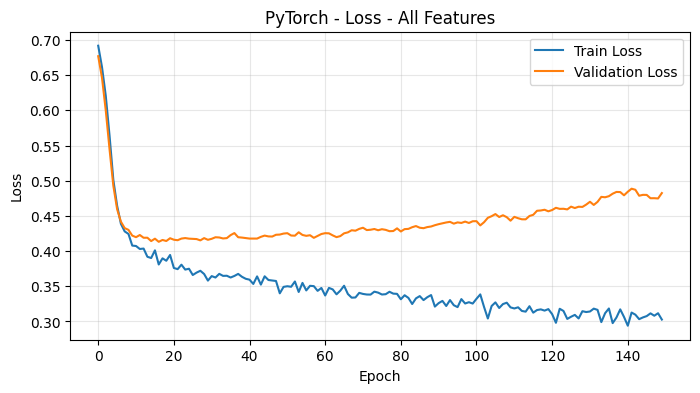

In [40]:
plt.figure(figsize=(8, 4))

plt.plot(
    history_all["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_all["val_loss"],
    label="Validation Loss"
)

plt.title("PyTorch - Loss - All Features")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

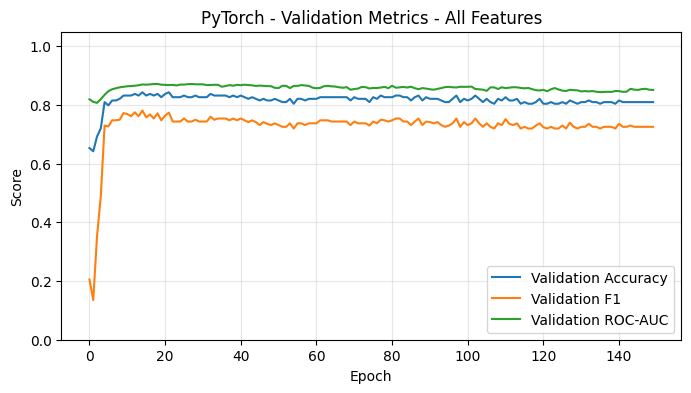

In [41]:
plt.figure(figsize=(8, 4))

plt.plot(
    history_all["val_accuracy"],
    label="Validation Accuracy"
)

plt.plot(
    history_all["val_f1"],
    label="Validation F1"
)

plt.plot(
    history_all["val_auc"],
    label="Validation ROC-AUC"
)

plt.title("PyTorch - Validation Metrics - All Features")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 21. Hàm đánh giá PyTorch

In [42]:
def evaluate_pytorch(
    model,
    X_t,
    y_true,
    title=""
):

    model.eval()

    with torch.no_grad():

        logits = model(
            X_t
        )

        prob = torch.sigmoid(
            logits
        ).cpu().numpy().ravel()

        pred = (
            prob >= 0.5
        ).astype(int)

    metrics = {
        "Accuracy": accuracy_score(
            y_true,
            pred
        ),

        "Precision": precision_score(
            y_true,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            prob
        )
    }

    print(title)

    for name, value in metrics.items():
        print(
            f"{name:10s}: "
            f"{value:.4f}"
        )

    print("\nClassification report:")

    print(
        classification_report(
            y_true,
            pred,
            zero_division=0
        )
    )

    return pred, prob, metrics

In [43]:
pred_nn_all, prob_nn_all, metrics_nn_all = evaluate_pytorch(
    model_all,
    X_val_all_t,
    y_val.values,
    title="PyTorch - All Features"
)

PyTorch - All Features
Accuracy  : 0.8380
Precision : 0.8448
Recall    : 0.7101
F1        : 0.7717
ROC-AUC   : 0.8719

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       110
           1       0.84      0.71      0.77        69

    accuracy                           0.84       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179



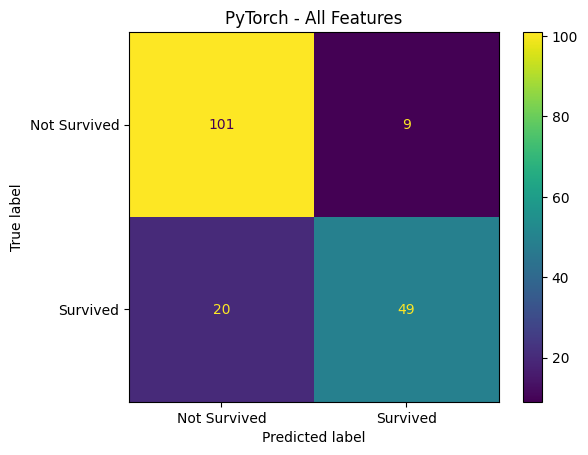

In [44]:
cm = confusion_matrix(
    y_val,
    pred_nn_all
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Survived",
        "Survived"
    ]
)

disp.plot()
plt.title("PyTorch - All Features")
plt.show()

## 22. PyTorch với các feature tốt nhất

In [45]:
model_best, history_best = train_titanic_model(
    X_train_t=X_train_best_t,
    y_train_t=y_train_t,
    X_val_t=X_val_best_t,
    y_val_np=y_val.values,
    hidden1=32,
    hidden2=16,
    dropout=0.20,
    learning_rate=0.001,
    batch_size=32,
    epochs=150,
    verbose_every=25
)

Epoch   1/150 | Train Loss=0.6924 | Val Acc=0.5978 | Val F1=0.1000 | Val AUC=0.6957


Epoch  25/150 | Train Loss=0.4492 | Val Acc=0.8045 | Val F1=0.7287 | Val AUC=0.8390


Epoch  50/150 | Train Loss=0.4231 | Val Acc=0.8045 | Val F1=0.7328 | Val AUC=0.8418


Epoch  75/150 | Train Loss=0.4037 | Val Acc=0.8045 | Val F1=0.7482 | Val AUC=0.8447


Epoch 100/150 | Train Loss=0.3929 | Val Acc=0.8101 | Val F1=0.7536 | Val AUC=0.8398


Epoch 125/150 | Train Loss=0.3989 | Val Acc=0.8045 | Val F1=0.7445 | Val AUC=0.8458


Epoch 150/150 | Train Loss=0.3855 | Val Acc=0.8045 | Val F1=0.7518 | Val AUC=0.8511
Training time: 6.12 seconds
Best Validation AUC: 0.8527


In [46]:
pred_nn_best, prob_nn_best, metrics_nn_best = evaluate_pytorch(
    model_best,
    X_val_best_t,
    y_val.values,
    title="PyTorch - Selected Features"
)

PyTorch - Selected Features
Accuracy  : 0.8045
Precision : 0.7429
Recall    : 0.7536
F1        : 0.7482
ROC-AUC   : 0.8527

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.75      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



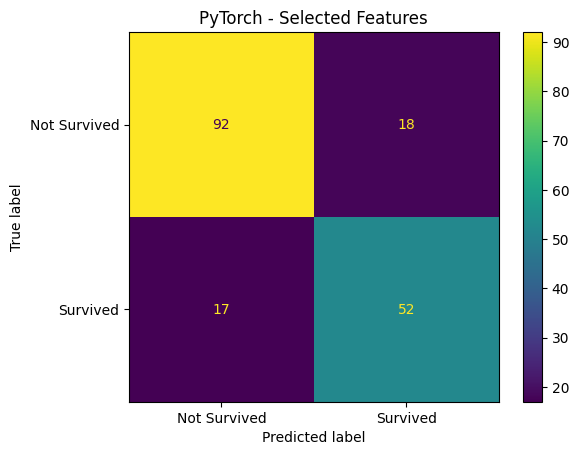

In [47]:
cm = confusion_matrix(
    y_val,
    pred_nn_best
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Survived",
        "Survived"
    ]
)

disp.plot()
plt.title("PyTorch - Selected Features")
plt.show()

## 23. So sánh kết quả

Ta so sánh:

- Dummy baseline
- Logistic Regression + selected features
- PyTorch + all encoded features
- PyTorch + selected features

In [48]:
summary = pd.DataFrame([
    {
        "Model": "Dummy",
        "Features": "Raw pipeline",
        "Accuracy": dummy_acc,
        "F1": f1_score(
            y_val,
            dummy_pred,
            zero_division=0
        ),
        "ROC-AUC": 0.5
    },

    {
        "Model": "Logistic Regression",
        "Features": f"Selected k={best_k}",
        "Accuracy": acc_lr,
        "F1": f1_lr,
        "ROC-AUC": auc_lr
    },

    {
        "Model": "PyTorch MLP",
        "Features": "All encoded",
        "Accuracy": metrics_nn_all["Accuracy"],
        "F1": metrics_nn_all["F1"],
        "ROC-AUC": metrics_nn_all["ROC-AUC"]
    },

    {
        "Model": "PyTorch MLP",
        "Features": f"Selected k={best_k}",
        "Accuracy": metrics_nn_best["Accuracy"],
        "F1": metrics_nn_best["F1"],
        "ROC-AUC": metrics_nn_best["ROC-AUC"]
    }
])

summary.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Features,Accuracy,F1,ROC-AUC
0,PyTorch MLP,All encoded,0.837989,0.771654,0.871937
1,PyTorch MLP,Selected k=10,0.804469,0.748201,0.852701
2,Logistic Regression,Selected k=10,0.782123,0.723404,0.844137
3,Dummy,Raw pipeline,0.614525,0.000000,0.500000


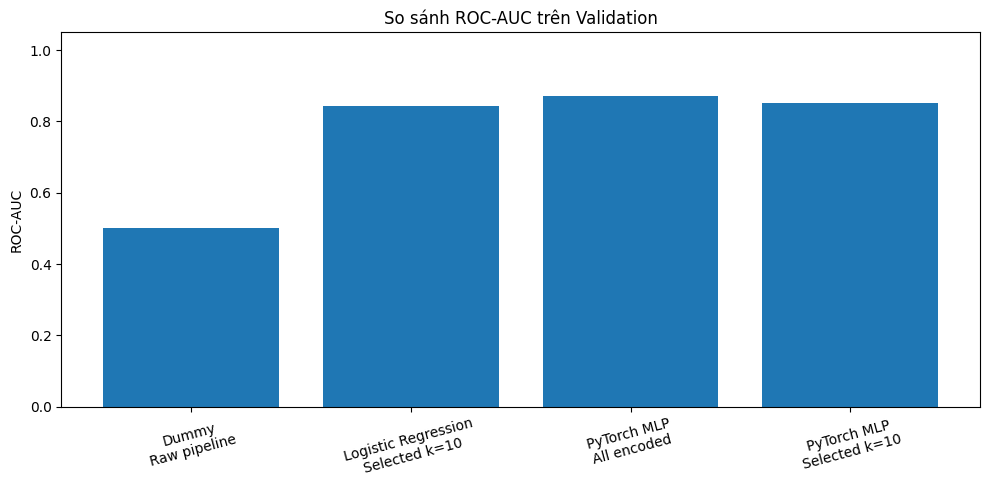

In [49]:
summary_plot = summary.copy()

summary_plot["Experiment"] = (
    summary_plot["Model"]
    + "\n"
    + summary_plot["Features"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    summary_plot["Experiment"],
    summary_plot["ROC-AUC"]
)

plt.title("So sánh ROC-AUC trên Validation")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 23.1 Quyết định tập đặc trưng cuối cùng

Kết quả so sánh phía trên cho thấy một điều quan trọng:

- Mutual Information chấm điểm **từng feature riêng lẻ**, không biết các feature kết hợp với nhau thế nào. One-hot encoding lại chia một biến (ví dụ `Pclass`, `Age` sau khi chuẩn hóa) thành nhiều cột có điểm thấp, nên các biến này dễ bị loại dù **thực sự hữu ích khi dùng chung với `Sex` và `Title`**.
- Vì vậy, chọn đặc trưng bằng MI + `SelectKBest` **không đảm bảo** cho mô hình tốt hơn dùng toàn bộ đặc trưng.

Quy tắc quyết định (chỉ dựa trên validation, không dùng Kaggle test):

> Dùng tập đặc trưng đã chọn nếu ROC-AUC của PyTorch không thấp hơn dùng toàn bộ đặc trưng quá `0.005`; ngược lại dùng toàn bộ đặc trưng.

Kết quả của quy tắc được in ra dưới đây và được dùng cho tuning, retrain và submission.

In [50]:
TOLERANCE = 0.005

auc_all = metrics_nn_all["ROC-AUC"]
auc_sel = metrics_nn_best["ROC-AUC"]

if auc_sel >= auc_all - TOLERANCE:
    FINAL_K = best_k
else:
    FINAL_K = "all"

print(f"ROC-AUC toàn bộ feature   : {auc_all:.4f}")
print(f"ROC-AUC feature đã chọn   : {auc_sel:.4f}  (k = {best_k})")
print(f"=> FINAL_K = {FINAL_K}")

# Tạo tensor cho tập đặc trưng cuối cùng (selector chỉ fit trên TRAIN)
final_selector_val = SelectKBest(score_func=mi_func, k=FINAL_K)

X_train_final_np = final_selector_val.fit_transform(X_train_all_np, y_train)
X_val_final_np = final_selector_val.transform(X_val_all_np)
X_kaggle_final_sel_np = final_selector_val.transform(X_kaggle_all_np)

X_train_final_t = to_tensor_x(X_train_final_np)
X_val_final_t = to_tensor_x(X_val_final_np)

print("Số feature dùng:", X_train_final_t.shape[1])

ROC-AUC toàn bộ feature   : 0.8719
ROC-AUC feature đã chọn   : 0.8527  (k = 10)
=> FINAL_K = all
Số feature dùng: 30


## 24. Phân tích các mẫu PyTorch dự đoán sai

Xem những hành khách nào bị mô hình dự đoán sai.

Điều này giúp chuyển từ:

> “Model đạt bao nhiêu %?”

sang:

> “Model sai ở loại dữ liệu nào?”

In [51]:
wrong_idx = np.where(
    pred_nn_best != y_val.values
)[0]

print(
    "Số mẫu dự đoán sai:",
    len(wrong_idx),
    "/",
    len(y_val)
)

error_df = X_val.iloc[
    wrong_idx
].copy()

error_df["Actual"] = (
    y_val.iloc[
        wrong_idx
    ].values
)

error_df["Predicted"] = (
    pred_nn_best[
        wrong_idx
    ]
)

error_df["Probability_Survived"] = (
    prob_nn_best[
        wrong_idx
    ]
)

error_df.head(20)

Số mẫu dự đoán sai: 35 / 179


,Age,SibSp,Parch,Fare,FamilySize,FarePerPerson,Pclass,Sex,Embarked,Title,IsAlone,CabinDeck,Actual,Predicted,Probability_Survived
553,22.00,0,0,7.2250,1,7.225000,3,male,C,Mr,1,U,1,0,0.105167
536,45.00,0,0,26.5500,1,26.550000,1,male,S,Rare,1,B,0,1,0.803600
455,29.00,0,0,7.8958,1,7.895800,3,male,C,Mr,1,U,1,0,0.106964
745,70.00,1,1,71.0000,3,23.666667,1,male,S,Rare,0,B,0,1,0.889085
297,2.00,1,2,151.5500,4,37.887500,1,female,S,Miss,0,C,0,1,0.964232
40,40.00,1,0,9.4750,2,4.737500,3,female,S,Mrs,0,U,0,1,0.569633
644,0.75,2,1,19.2583,4,4.814575,3,female,C,Miss,0,U,1,0,0.446808
564,NaN,0,0,8.0500,1,8.050000,3,female,S,Miss,1,U,0,1,0.629025
502,NaN,0,0,7.6292,1,7.629200,3,female,Q,Miss,1,U,0,1,0.622136
17,NaN,0,0,13.0000,1,13.000000,2,male,S,Mr,1,U,1,0,0.121036


## 25. Tinh chỉnh kiến trúc PyTorch đơn giản

Ta thử một vài cấu hình mạng.

Lưu ý:

- Đây là minh họa tuning đơn giản.
- Không nên thử quá nhiều cấu hình rồi liên tục chọn theo cùng một validation set.
- Trong bài toán nghiêm túc nên dùng nested CV hoặc một test set độc lập.
- Tuning được thực hiện trên tập đặc trưng `FINAL_K` đã quyết định ở mục 23.1.

In [52]:
configs = [
    {
        "hidden1": 16,
        "hidden2": 8,
        "dropout": 0.10,
        "lr": 0.001
    },

    {
        "hidden1": 32,
        "hidden2": 16,
        "dropout": 0.20,
        "lr": 0.001
    },

    {
        "hidden1": 64,
        "hidden2": 32,
        "dropout": 0.30,
        "lr": 0.001
    }
]

tuning_results = []

for cfg in configs:

    print("\nConfig:", cfg)

    model_cfg, _ = train_titanic_model(
        X_train_t=X_train_final_t,
        y_train_t=y_train_t,
        X_val_t=X_val_final_t,
        y_val_np=y_val.values,
        hidden1=cfg["hidden1"],
        hidden2=cfg["hidden2"],
        dropout=cfg["dropout"],
        learning_rate=cfg["lr"],
        batch_size=32,
        epochs=100,
        verbose_every=100
    )

    _, _, metrics_cfg = evaluate_pytorch(
        model_cfg,
        X_val_final_t,
        y_val.values,
        title=""
    )

    tuning_results.append({
        **cfg,
        **metrics_cfg,
        "model": model_cfg
    })


Config: {'hidden1': 16, 'hidden2': 8, 'dropout': 0.1, 'lr': 0.001}


Epoch   1/100 | Train Loss=0.6916 | Val Acc=0.6648 | Val F1=0.3023 | Val AUC=0.7813


Epoch 100/100 | Train Loss=0.3387 | Val Acc=0.8101 | Val F1=0.7302 | Val AUC=0.8618
Training time: 4.41 seconds
Best Validation AUC: 0.8727

Accuracy  : 0.8268
Precision : 0.8065
Recall    : 0.7246
F1        : 0.7634
ROC-AUC   : 0.8727

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179


Config: {'hidden1': 32, 'hidden2': 16, 'dropout': 0.2, 'lr': 0.001}
Epoch   1/100 | Train Loss=0.6918 | Val Acc=0.6536 | Val F1=0.2051 | Val AUC=0.8196


Epoch 100/100 | Train Loss=0.3255 | Val Acc=0.8212 | Val F1=0.7419 | Val AUC=0.8621
Training time: 4.43 seconds
Best Validation AUC: 0.8719

Accuracy  : 0.8380
Precision : 0.8448
Recall    : 0.7101
F1        : 0.7717
ROC-AUC   : 0.8719

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       110
           1       0.84      0.71      0.77        69

    accuracy                           0.84       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179


Config: {'hidden1': 64, 'hidden2': 32, 'dropout': 0.3, 'lr': 0.001}
Epoch   1/100 | Train Loss=0.6540 | Val Acc=0.6145 | Val F1=0.0000 | Val AUC=0.8569


Epoch 100/100 | Train Loss=0.2868 | Val Acc=0.8156 | Val F1=0.7402 | Val AUC=0.8453
Training time: 4.58 seconds
Best Validation AUC: 0.8705

Accuracy  : 0.8380
Precision : 0.8448
Recall    : 0.7101
F1        : 0.7717
ROC-AUC   : 0.8705

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       110
           1       0.84      0.71      0.77        69

    accuracy                           0.84       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179



In [53]:
tuning_df = pd.DataFrame([
    {
        k: v
        for k, v in row.items()
        if k != "model"
    }
    for row in tuning_results
])

tuning_df.sort_values(
    "ROC-AUC",
    ascending=False
)

,hidden1,hidden2,dropout,lr,Accuracy,Precision,Recall,F1,ROC-AUC
0,16,8,0.1,0.001,0.826816,0.806452,0.724638,0.763359,0.872727
1,32,16,0.2,0.001,0.837989,0.844828,0.710145,0.771654,0.871937
2,64,32,0.3,0.001,0.837989,0.844828,0.710145,0.771654,0.870487


In [54]:
best_tuning_result = max(
    tuning_results,
    key=lambda x: x["ROC-AUC"]
)

best_model = best_tuning_result["model"]

print("Cấu hình PyTorch tốt nhất:")
print(
    "hidden1 =",
    best_tuning_result["hidden1"]
)
print(
    "hidden2 =",
    best_tuning_result["hidden2"]
)
print(
    "dropout =",
    best_tuning_result["dropout"]
)
print(
    "lr      =",
    best_tuning_result["lr"]
)
print(
    "ROC-AUC =",
    round(
        best_tuning_result["ROC-AUC"],
        4
    )
)

Cấu hình PyTorch tốt nhất:
hidden1 = 16
hidden2 = 8
dropout = 0.1
lr      = 0.001
ROC-AUC = 0.8727


## 26. Dự đoán tập test Kaggle

Dùng mô hình tốt nhất đã chọn trên validation.

Ở đây sử dụng bộ tiền xử lý và selector đã fit trên tập train con.

Đây là cách đơn giản, phù hợp mục tiêu thực hành.

> Ở phần tiếp theo, **retrain trên toàn bộ train.csv** trước khi tạo submission cuối cùng.

> Mô hình dùng tập đặc trưng `FINAL_K` (mục 23.1).

In [55]:
X_kaggle_best_t = to_tensor_x(
    X_kaggle_final_sel_np
)

best_model.eval()

with torch.no_grad():

    kaggle_logits = best_model(
        X_kaggle_best_t
    )

    kaggle_prob = torch.sigmoid(
        kaggle_logits
    ).cpu().numpy().ravel()

    kaggle_pred_quick = (
        kaggle_prob >= 0.5
    ).astype(int)

print(
    "Số dự đoán:",
    len(kaggle_pred_quick)
)

print(
    kaggle_pred_quick[:20]
)

Số dự đoán: 418
[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]


## 27. Retrain PyTorch trên toàn bộ `train.csv`

Sau khi đã:

- chọn feature,
- chọn kiến trúc,
- chọn learning rate,

ta có thể sử dụng toàn bộ dữ liệu có nhãn để huấn luyện lại mô hình cuối cùng.

### Quy trình

```text
FULL TRAIN
   ↓
Fit Preprocessor
   ↓
Fit SelectKBest
   ↓
Train final MLP
   ↓
Predict TEST
```

Ở bước final train, không còn validation nội bộ; ta dùng số epoch cố định đã chọn từ giai đoạn trước.
> **Lưu ý:** tập đặc trưng dùng ở bước này là `FINAL_K` (được quyết định ở mục 23.1 dựa trên so sánh *toàn bộ feature* với *feature đã chọn* trên validation).

In [56]:
# 1. Fit preprocessor trên toàn bộ dữ liệu train
final_preprocessor = preprocessor

X_full_np = final_preprocessor.fit_transform(
    X
)

X_kaggle_final_np = final_preprocessor.transform(
    X_kaggle
)

# 2. Fit selector trên toàn bộ dữ liệu train
final_selector = SelectKBest(
    score_func=mi_func,
    k=FINAL_K
)

X_full_selected_np = final_selector.fit_transform(
    X_full_np,
    y
)

X_kaggle_selected_np = final_selector.transform(
    X_kaggle_final_np
)

print(
    "Full train selected:",
    X_full_selected_np.shape
)

print(
    "Kaggle selected   :",
    X_kaggle_selected_np.shape
)

Full train selected: (891, 30)
Kaggle selected   : (418, 30)


In [57]:
X_full_t = to_tensor_x(
    X_full_selected_np
)

y_full_t = to_tensor_y(
    y.values
)

X_kaggle_final_t = to_tensor_x(
    X_kaggle_selected_np
)


torch.manual_seed(SEED)

final_model = TitanicMLP(
    input_size=X_full_t.shape[1],
    hidden1=best_tuning_result["hidden1"],
    hidden2=best_tuning_result["hidden2"],
    dropout=best_tuning_result["dropout"]
)

final_loader = DataLoader(
    TensorDataset(
        X_full_t,
        y_full_t
    ),
    batch_size=32,
    shuffle=True
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_tuning_result["lr"]
)

FINAL_EPOCHS = 100

for epoch in range(
    1,
    FINAL_EPOCHS + 1
):

    final_model.train()

    total_loss = 0.0

    for xb, yb in final_loader:

        optimizer.zero_grad()

        logits = final_model(
            xb
        )

        loss = criterion(
            logits,
            yb
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * len(xb)
        )

    if (
        epoch == 1
        or epoch % 20 == 0
    ):

        avg_loss = (
            total_loss
            / len(X_full_t)
        )

        print(
            f"Epoch {epoch:3d}/"
            f"{FINAL_EPOCHS} | "
            f"Loss={avg_loss:.4f}"
        )

Epoch   1/100 | Loss=0.6899


Epoch  20/100 | Loss=0.4115


Epoch  40/100 | Loss=0.3797


Epoch  60/100 | Loss=0.3594


Epoch  80/100 | Loss=0.3565


Epoch 100/100 | Loss=0.3445


## 28. Tạo Kaggle Submission

In [58]:
final_model.eval()

with torch.no_grad():

    final_logits = final_model(
        X_kaggle_final_t
    )

    final_prob = torch.sigmoid(
        final_logits
    ).cpu().numpy().ravel()

    final_pred = (
        final_prob >= 0.5
    ).astype(int)


submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_pred
})

submission.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [59]:
submission.to_csv(
    "submission_titanic_pytorch.csv",
    index=False
)

print(
    "Đã tạo: "
    "submission_titanic_pytorch.csv"
)

print(
    "Shape:",
    submission.shape
)

print(
    "Phân bố dự đoán:"
)

print(
    submission["Survived"]
    .value_counts()
    .sort_index()
)

Đã tạo: submission_titanic_pytorch.csv
Shape: (418, 2)
Phân bố dự đoán:
Survived
0    268
1    150
Name: count, dtype: int64


## 29. Kiểm tra file submission

In [60]:
check_submission = pd.read_csv(
    "submission_titanic_pytorch.csv"
)

print(check_submission.head())

print()
check_submission.info()

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


## 29.1 Nhận xét kết quả thực nghiệm

**Đặc trưng quan trọng.** Theo Mutual Information (tập train), các cột có nhiều thông tin nhất về `Survived` là `Sex` (`Sex_male` ≈ 0.16, `Sex_female` ≈ 0.15), `Fare` (≈ 0.16), `Title_Mr` (≈ 0.15) và `FarePerPerson` (≈ 0.14). Điều này khớp với EDA: nữ giới và nhóm danh xưng `Mrs`/`Miss` sống sót cao hơn nhiều. Các đặc trưng tự tạo (`Title`, `FamilySize`, `FarePerPerson`, `CabinDeck_U` – "không có thông tin cabin") đều nằm trong nhóm đầu.

**Chọn số lượng đặc trưng.** CV ROC-AUC tăng dần theo `k` (≈ 0.852 với k = 5 → 0.869 với 30 đặc trưng). Dùng quy tắc 1-SE, ta chọn **k = 10** (ROC-AUC 0.860, so với 0.869 khi dùng cả 30), tức giảm 2/3 số đặc trưng mà chỉ mất ≈ 0.008 AUC trong Cross-Validation.

**So sánh trên validation (179 hành khách).**

| Mô hình | Đặc trưng | Accuracy | F1 | ROC-AUC |
|---|---|---|---|---|
| Dummy (luôn đoán "không sống") | – | 0.615 | 0.000 | 0.500 |
| Logistic Regression | k = 10 | 0.782 | 0.723 | 0.844 |
| PyTorch MLP | k = 10 | 0.804 | 0.748 | 0.853 |
| PyTorch MLP | toàn bộ 30 | **0.838** | **0.772** | **0.872** |

- Mọi mô hình đều vượt xa baseline Dummy.
- **Trong lần chạy này, dùng toàn bộ đặc trưng tốt hơn dùng 10 đặc trưng chọn bằng MI** (AUC 0.872 so với 0.853). Lý do hợp lý: MI chấm điểm *từng cột riêng lẻ* nên đã loại `Pclass` và `Age` — những biến chỉ phát huy khi kết hợp với `Sex`/`Title` — và One-Hot chia mỗi biến phân loại thành nhiều cột điểm thấp. Vì thế kết luận "SelectKBest bằng MI luôn giúp ích" **không đúng** ở đây; quy tắc ở mục 23.1 chọn tập toàn bộ đặc trưng cho submission cuối.
- Trong Cross-Validation (k = 10) Random Forest (AUC 0.863) và Logistic Regression (0.860) gần như ngang nhau và nhỉnh hơn SVM-RBF (0.845): với dữ liệu bảng nhỏ, mô hình đơn giản cạnh tranh được với mạng nơ-ron.

**Độ tin cậy.** Validation chỉ có 179 mẫu nên 1 mẫu ≈ 0.56% accuracy; các chênh lệch dưới ~1–2% (ví dụ giữa ba cấu hình MLP ở mục 25: AUC 0.870–0.873) **không đủ để kết luận cấu hình nào tốt hơn**. Validation còn được dùng để chọn epoch tốt nhất và chọn cấu hình, nên các con số trên hơi lạc quan; đánh giá khách quan hơn cần nested CV hoặc một test set riêng. Điểm Kaggle thực tế thường thấp hơn điểm validation vài phần trăm.

**Lỗi của mô hình.** Mô hình sai tập trung ở hai nhóm đi ngược xu hướng chung: **nữ hạng 3** (tỉ lệ sai 29–36%, vì chỉ khoảng một nửa số họ sống sót) và **nam hạng nhất** (tỉ lệ sai 33–50%, vì 37% số họ sống sót); các nhóm còn lại sai dưới ~12%. Recall của lớp "sống sót" (≈ 0.71–0.75) cũng thấp hơn lớp "không sống sót".


## 30. Kết luận

Pipeline của bài:

```text
Titanic
   │
   ▼
Data Inspection
   │
   ▼
EDA
   │
   ▼
Feature Engineering
   │
   ├── Title
   ├── FamilySize
   ├── IsAlone
   ├── CabinDeck
   └── FarePerPerson
   │
   ▼
Train / Validation Split
   │
   ▼
ColumnTransformer
   ├── Numeric
   │    ├── Median Imputation
   │    └── StandardScaler
   │
   └── Categorical
        ├── Mode Imputation
        └── One-Hot Encoding
   │
   ▼
Feature Selection
   ├── Mutual Information
   └── SelectKBest + Cross-Validation
   │
   ├───────────────┐
   ▼               ▼
Scikit-Learn     PyTorch
   │               │
   ▼               ▼
Evaluation      MLP Training
   │               │
   └───────┬───────┘
           ▼
        Compare
           │
           ▼
       Retrain Full
           │
           ▼
     Kaggle Submission
```

### Các điểm cần nhớ

1. Không nên điền missing trên toàn bộ dataset trước khi chia train/validation.
2. Imputer, scaler, encoder và feature selector chỉ được `fit` trên train.
3. `Sex`, `Pclass`, `Title`, `Fare`, `Age` và các feature gia đình thường cung cấp nhiều thông tin cho bài toán.
4. Feature engineering có thể quan trọng không kém việc đổi model.
5. Mutual Information cho biết feature nào chứa thông tin về nhãn, nhưng không nên là tiêu chí duy nhất.
6. Nên dùng Cross-Validation để chọn số feature.
7. Accuracy chưa đủ; cần xem F1 và ROC-AUC.
8. Deep Learning không tự động tốt hơn Machine Learning truyền thống trên dữ liệu bảng nhỏ.
9. Với PyTorch binary classification, `BCEWithLogitsLoss` thường phù hợp hơn việc tự đặt Sigmoid rồi dùng BCE.
10. Sau khi hoàn tất tuning, có thể retrain trên toàn bộ dữ liệu có nhãn trước khi dự đoán Kaggle test.

## 31. Câu hỏi thảo luận

1. Tại sao `PassengerId` không nên được coi là feature quan trọng?
2. Vì sao `Name` có thể bỏ nhưng `Title` lại hữu ích?
3. `FamilySize` có thể tốt hơn dùng riêng `SibSp` và `Parch` trong trường hợp nào?
4. Vì sao không dùng giá trị trung bình của toàn bộ train + test để điền `Age`?
5. Tại sao `OneHotEncoder(handle_unknown="ignore")` quan trọng?
6. Mutual Information khác correlation ở điểm nào?
7. Tại sao chọn feature trên validation rồi lại đánh giá trên chính validation là không tốt?
8. Khi nào Random Forest phù hợp hơn Logistic Regression?
9. Vì sao mạng PyTorch không cần quá sâu cho Titanic?
10. Accuracy cao nhưng Recall của lớp sống sót thấp có phải là mô hình tốt không?

## 32. Bài tập mở rộng

- Thêm feature `AgeGroup`.
- Thêm feature `FareGroup`.
- Khai thác `Ticket` để tạo `TicketPrefix`.
- Khai thác số người dùng chung một ticket.
- Thử `RandomForest`, `XGBoost`, `LightGBM`, `CatBoost`.
- Thử `SelectFromModel`.
- Thử permutation importance.
- Thử điều chỉnh threshold thay vì cố định `0.5`.
- So sánh Accuracy/F1/AUC trước và sau Feature Engineering.
- Thực hiện Stratified K-Fold cho mô hình PyTorch.